# Chapter 4: Results and Benchmarking
**Supplementary Code for Dissertation Figure 4.1 & Table 4.1**

This notebook analyses the computational efficiency of the exact Gillespie Algorithm (SSA) against the deterministic Euler method (ODEs) and the stochastic Chemical Langevin Equation (SDEs via Euler-Maruyama).

### Reproducibility Workflow
To accommodate the high computational cost of exact spatial simulations (the $100 \times 100$ SSA requires $\approx 4$ hours), this notebook is decoupled from the data generation:
1. **Canonical Data:** By default, the notebook loads the exact results used in the dissertation text.
2. **Custom Data:** Users can generate new timings by executing `scripts/run_benchmarks.py`. 
3. **Toggle:** Setting `LOAD_CUSTOM_DATA = True` in the following cell will switch the analysis to use the newly generated local data.

In [1]:
# Environment Setup & Module Imports
import sys
import os
import time
import jax
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jsmfsb

# Route imports to the src folder
sys.path.append(os.path.abspath('..'))

# Enable autoreload for custom modules
%load_ext autoreload
%autoreload 2

# Academic Plotting
sns.set_theme(style='ticks')
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

### Data Loading and Source Toggle
The following cell initialises the benchmark data. If `LOAD_CUSTOM_DATA` is enabled, the notebook attempts to read `data/custom_benchmarks.csv`. Otherwise, it falls back to the hardcoded canonical results used for the dissertation submission.

In [2]:
# Data Loading & Configuration

# --- TOGGLE THIS ---
# False = Use hardcoded  data for dissertation submission
# True = Load the newly generated CSV from standalone script
LOAD_CUSTOM_DATA = False

config_order = [
    'Non-spatial', '1D (N=20)', '1D (N=50)',
    '2D (20×20)', '2D (50×50)', '2D (100×100)'
]

if LOAD_CUSTOM_DATA and os.path.exists('../data/custom_benchmarks.csv'):
    print("Loading freshly generated data from scripts/run_benchmarks.py...")
    df = pd.read_csv('../data/custom_benchmarks.csv')
else:
    print("Loading pre-computed data for dissertation...")
    df = pd.DataFrame({
        'Configuration': [
            'Non-spatial', 'Non-spatial', 'Non-spatial',
            '1D (N=20)', '1D (N=20)', '1D (N=20)',
            '1D (N=50)', '1D (N=50)', '1D (N=50)',
            '2D (20×20)', '2D (20×20)', '2D (20×20)',
            '2D (50×50)', '2D (50×50)', '2D (50×50)',
            '2D (100×100)', '2D (100×100)', '2D (100×100)',
        ],
        'Method': ['SSA', 'Euler', 'CLE'] * 6,
        'Time (s)': [
            0.1165, 0.0322, 0.0743,
            0.8626, 0.0476, 0.1697,
            1.5789, 0.0485, 0.1792,
            73.2206, 0.0472, 0.3699,
            1040.0956, 0.0625, 1.0662,
            14560.0, 0.1188, 1.7889,
        ]
    })

Loading pre-computed data for dissertation...


### Table 4.1: Quantitative Comparison of Execution Times
This table presents the raw execution times (in seconds) across different spatial complexities. The data displayed here corresponds to the source selected in the loading toggle above.

In [3]:
# Table 4.1 Generation

table_4_1 = df.pivot(index='Configuration', columns='Method', values='Time (s)')
table_4_1 = table_4_1.reindex(config_order)
table_4_1 = table_4_1[['SSA', 'Euler', 'CLE']]

display(table_4_1.style.format("{:.4f}").set_caption("Table 4.1: Execution time (seconds) across simulation methods and spatial grids."))

# Export
table_4_1.to_csv('../Dissertation_Figures/Table4_1_Benchmarking.csv')

Method,SSA,Euler,CLE
Configuration,,,
Non-spatial,0.1165,0.0322,0.0743
1D (N=20),0.8626,0.0476,0.1697
1D (N=50),1.5789,0.0485,0.1792
2D (20×20),73.2206,0.0472,0.3699
2D (50×50),1040.0956,0.0625,1.0662
2D (100×100),14560.0000,0.1188,1.7889


### Figure 4.1: Visualisation of Computational Scaling
A logarithmic bar chart illustrating the performance gap between exact discrete simulation and continuous approximations.

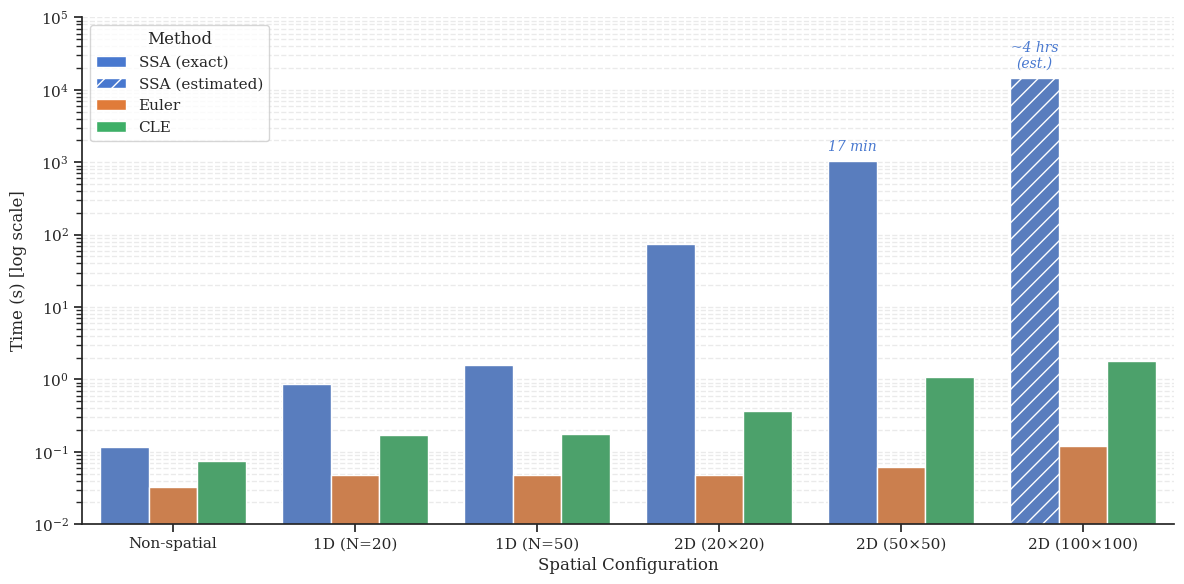

In [4]:
# Plotting Figure 4.1
from matplotlib.patches import Patch

palette = {'SSA': '#4878CF', 'Euler': '#E07B39', 'CLE': '#3EAF67'}
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df, x='Configuration', y='Time (s)', hue='Method',
    order=config_order, hue_order=['SSA', 'Euler', 'CLE'],
    palette=palette, ax=ax
)

ax.set_yscale('log')
ax.set_ylim(1e-2, 1e5)
ax.set_ylabel('Time (s) [log scale]')
ax.set_xlabel('Spatial Configuration')
ax.yaxis.grid(True, which='both', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# --- DYNAMIC HATCHING LOGIC ---
# Extract the execution time for the 100x100 SSA configuration
val_100x100_ssa = df.loc[(df['Configuration'] == '2D (100×100)') & (df['Method'] == 'SSA'), 'Time (s)'].values[0]

# Check if it matches our exact hardcoded estimate
is_estimated = (val_100x100_ssa == 14560.0)

if is_estimated:
    # Apply hatch to the 100x100 SSA bar (index 5)
    ax.patches[5].set_hatch('//')
    ax.patches[5].set_edgecolor('white')
    label_100 = '~4 hrs\n(est.)'
else:
    # If custom data, calculate their actual run time in hours
    actual_hours = val_100x100_ssa / 3600
    label_100 = f'{actual_hours:.1f} hrs'

for idx, label in [(4, '17 min'), (5, label_100)]:
    bar = ax.patches[idx]
    x = bar.get_x() + bar.get_width() / 2
    y_pos = bar.get_height() * 1.25 # Dynamically place text slightly above the bar
    ax.text(x, y_pos, label, ha='center', va='bottom', fontsize=10, color='#4878CF', style='italic')

# --- DYNAMIC LEGEND ---
legend_handles = [Patch(facecolor='#4878CF', label='SSA (exact)')]

if is_estimated:
    legend_handles.append(Patch(facecolor='#4878CF', hatch='//', edgecolor='white', label='SSA (estimated)'))
    
legend_handles.extend([
    Patch(facecolor='#E07B39', label='Euler'),
    Patch(facecolor='#3EAF67', label='CLE')
])

ax.legend(handles=legend_handles, frameon=True, title='Method')
sns.despine()
plt.tight_layout()

plt.savefig('../Dissertation_Figures/Fig4_1_Benchmarking.png', dpi=300, bbox_inches='tight')
plt.show()